In [51]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import copy

sys.path.append(os.path.abspath('..'))
from algorithms.auxiliares import *
from algorithms.neural_network import *

In [52]:
class K_fold():
    def __init__(self, modelos, k, muestreo_estratificado=False):
        self.modelos = modelos
        self.k = k
        self.metricas_modelos = [] #k * modelos
        self.matrices_confusion = []
        self.muestreo_estratificado = muestreo_estratificado

    
    def cross_val(self, X, y): # Recibe dataset completo
        N = X.shape[0]
        fold_size = N//self.k
        proporcion_test = 1/self.k

        idx = np.arange(N)
        np.random.shuffle(idx)

        self.metricas_modelos = [] # k_i x modelo_i

        for i in range(self.k): #                
            if self.muestreo_estratificado:
                if y.ndim > 1:
                    y_labels = np.argmax(y, axis=1)
                else:
                    y_labels = y

                clases = np.unique(y_labels)
                indices = [] # clases x indices? Irregular, es lista
                cant_elementos_test = []

                for clase in clases:
                    idx_clase = np.where(y_labels==clase)[0]
                    indices.append(idx_clase)

                    elemento_test = int(proporcion_test * len(idx_clase))
                    cant_elementos_test.append(elemento_test) 

                idx_select = []

                for idx_clase, n_test in zip(indices, cant_elementos_test):
                    np.random.shuffle(idx_clase)
                    idx_select.extend(idx_clase[:n_test])
                
                idx_select = np.array(idx_select)

                mask = np.ones(N, dtype=bool)
                mask[idx_select] = False
                        
                X_train, X_test = X[mask], X[idx_select]

                if y.ndim == 1:
                    y_test = y[idx_select].reshape(-1,1)
                    y_train = y[mask].reshape(-1,1)
                else:
                    y_test = y[idx_select]
                    y_train = y[mask]
            else:

                idx_select = idx[i*fold_size : (i+1)*fold_size-1]

                mask = np.ones(N, dtype=bool)
                mask[idx_select] = False
                        
                X_train, X_test = X[mask], X[idx_select]

                if y.ndim == 1:
                    y_test = y[idx_select].reshape(-1,1)
                    y_train = y[mask].reshape(-1,1)
                else:
                    y_test = y[idx_select]
                    y_train = y[mask]


            idx = np.arange(X_train.shape[0])
            np.random.shuffle(idx)
            
            metrics = [] 
            cms = []
            for modelo in self.modelos: #recorremos cada modelos          
                modelo_copy = copy.deepcopy(modelo)
                modelo_copy.idx_shuffle = idx

                # Ahora si intercambiamos edades -1 por la media
                edad_media = np.mean(X_train[:,33])
                X_train[X_train[:,33] == -1, 33] = edad_media
                X_test[X_test[:,33] == -1, 33] = edad_media

                # Diferentes escalas de datos en features
                media = np.mean(X_train, axis=0)
                std = np.std(X_train, axis=0)
                X_train = (X_train - media) / std
                X_test = (X_test - media) / std

                modelo_copy.fit(X_train, y_train)
                metrica = modelo_copy.score(X_test, y_test)
                metrics.append(metrica)

                cm = modelo_copy.confusion_matrix(X_test, y_test)
                cms.append(cm)

            self.metricas_modelos.append(metrics)
            self.matrices_confusion.append(cms)

            #en lugar
        return np.mean(self.metricas_modelos, axis=1), np.std(self.metricas_modelos, axis=1)
    
    def obtener_conteos_globales(self, cm):
        n = cm.shape[0]
        total = np.sum(cm)

        TP = np.diag(cm)
        # Como en la suma incluímos los verdaderos positivos, tenemos que restarlos
        FN = np.sum(cm, axis=1) - TP # Sumamos toda la fila para cada columna.
        FP = np.sum(cm, axis=0) - TP # Sumamos toda la columna para cada fila
        TN = total - (TP + FN + FP)

        return np.sum(TP), np.sum(TN), np.sum(FP), np.sum(FN)

    def obtener_cm_clases(self, cm_global):
        n_clases = cm_global.shape[0]
        cm_clases = []

        for i in range(n_clases):
            # Primero creamos una matriz de confusión que
            # tenga una columna para la clase correcta
            # y otra que represente a todas las demás
            cm_clase = np.array([
                [0, 0],
                [0, 0]
            ])
            cm_clase[0,0] = cm_global[i,i] # la diagonal ya nos da los TP de la clase
            cm_clase[0,1] = np.sum(cm_global[i,:]) - cm_clase[0,0] # los FN
            cm_clase[1,0] = np.sum(cm_global[:,i]) - cm_clase[0,0] # Los FP
            cm_clase[1,1] = np.sum(cm_global) - np.sum(cm_clase)
            cm_clases.append(cm_clase)
        return np.array(cm_clases)

    def calcular_metrica_global_y_por_clase(self,  metodo):
        global_metric = [] # n_modelos 
        metric_by_class = [] # n_modelos x n_clases
        
        match metodo:
            case 'exactitud':
                # calculo de metricas globales
                
                for m in range(len(self.modelos)):
                    cm_sum = np.zeros_like(self.matrices_confusion[0][m])

                    for k in range(self.k):
                        cm_sum += self.matrices_confusion[k][m]

                    cm = cm_sum / self.k # matriz confusión global

                    # global
                    TP, TN, FP, FN = self.obtener_conteos_globales(cm)
                    exactitud_global = (TP + TN) / (TP + TN + FP + FN)
                    global_metric.append(exactitud_global)

                    # por clase 
                    cm_clases = self.obtener_cm_clases(cm)
                    metrics_classes = []
                    for cm in cm_clases:
                        TP, TN, FP, FN = cm[0,0], cm[1,1], cm[1,0], cm[0,1]
                        exactitud = (TP + TN) / (TP + TN + FP + FN)
                        metrics_classes.append(exactitud)
                    metric_by_class.append(metrics_classes) 
            
            case 'sensibilidad':
                # calculo de metricas globales
                for m in range(len(self.modelos)):
                    cm_sum = np.zeros_like(self.matrices_confusion[0][m])

                    for k in range(self.k):
                        cm_sum += self.matrices_confusion[k][m]

                    cm = cm_sum / self.k # matriz confusión global

                    # global
                    TP, TN, FP, FN = self.obtener_conteos_globales(cm)
                    sensibilidad_global = (TP) / (TP + FN)
                    global_metric.append(sensibilidad_global)

                    # por clase 
                    cm_clases = self.obtener_cm_clases(cm)
                    metrics_classes = []
                    for cm in cm_clases:
                        TP, TN, FP, FN = cm[0,0], cm[1,1], cm[1,0], cm[0,1]
                        sensibilidad = (TP) / (TP + FN)
                        metrics_classes.append(sensibilidad)
                    metric_by_class.append(metrics_classes)

            case 'precision':
                # calculo de metricas globales
                for m in range(len(self.modelos)):
                    cm_sum = np.zeros_like(self.matrices_confusion[0][m])

                    for k in range(self.k):
                        cm_sum += self.matrices_confusion[k][m]

                    cm = cm_sum / self.k # matriz confusión global

                    # global
                    TP, TN, FP, FN = self.obtener_conteos_globales(cm)
                    precision_global = (TP) / (TP + FP)
                    global_metric.append(precision_global)

                    # por clase 
                    cm_clases = self.obtener_cm_clases(cm)
                    metrics_classes = []
                    for cm in cm_clases:
                        TP, TN, FP, FN = cm[0,0], cm[1,1], cm[1,0], cm[0,1]
                        precision = (TP) / (TP + FP)
                        metrics_classes.append(precision)
                    metric_by_class.append(metrics_classes)

            case 'especificidad':
                # calculo de metricas globales
                for m in range(len(self.modelos)):
                    cm_sum = np.zeros_like(self.matrices_confusion[0][m])

                    for k in range(self.k):
                        cm_sum += self.matrices_confusion[k][m]

                    cm = cm_sum / self.k # matriz confusión global

                    # global
                    TP, TN, FP, FN = self.obtener_conteos_globales(cm)
                    especificidad_global = (TN) / (TN + FP)
                    global_metric.append(especificidad_global)

                    # por clase 
                    cm_clases = self.obtener_cm_clases(cm)
                    metrics_classes = []
                    for cm in cm_clases:
                        TP, TN, FP, FN = cm[0,0], cm[1,1], cm[1,0], cm[0,1]
                        especificidad = (TN) / (TN + FP)
                        metrics_classes.append(especificidad)
                    metric_by_class.append(metrics_classes)

            case 'F1':
                # calculo de metricas globales
                for m in range(len(self.modelos)):
                    cm_sum = np.zeros_like(self.matrices_confusion[0][m])

                    for k in range(self.k):
                        cm_sum += self.matrices_confusion[k][m]

                    cm = cm_sum / self.k # matriz confusión global

                    # global
                    TP, TN, FP, FN = self.obtener_conteos_globales(cm)
                    precision = TP / (TP + FP)
                    sensibilidad = TP / (TP + FN)

                    F1_global = 2 * (precision * sensibilidad)/(precision + sensibilidad)
                    global_metric.append(F1_global)

                    # por clase 
                    cm_clases = self.obtener_cm_clases(cm)
                    metrics_classes = []
                    for cm in cm_clases:
                        TP, TN, FP, FN = cm[0,0], cm[1,1], cm[1,0], cm[0,1]
                        precision = (TP) / (TP + FP)
                        sensibilidad = TP / (TP + FN)
                        F1 = 2 * (precision * sensibilidad)/(precision + sensibilidad)

                        metrics_classes.append(F1)
                    metric_by_class.append(metrics_classes)

        return np.array(global_metric), np.array(metric_by_class)


In [53]:
ruta_data = os.path.abspath('../data')

X, y = cargar_datos_csv(os.path.join(ruta_data, 'dermatology.csv'))

X = np.array(X)

# encontrar la moda
valores, counts = np.unique(y, return_counts=True)
moda = valores[np.argmax(counts)]

#print(X[0,:])

# construir array binario
y = (y == moda).astype(int).flatten()
y = 2*y - 1

#print(moda)  
#print(y)  

# El ganador fue psoriasis!!
# Hay 8 personas cuya edad tiene un '?', hice que al importar el dataset
# se ponga -1, así reemplazamos tras splittear con la media.

y = np.array(y)
print(X.shape, y.shape, np.mean(y))

(366, 34) (366,) -0.3879781420765027


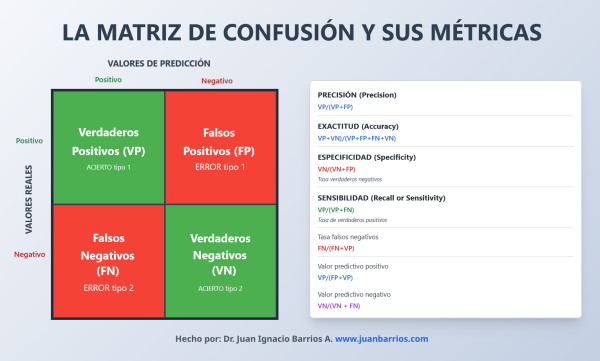

In [54]:
modelos = []
for i in range(3):
    model = neural_network(
        layers_config = [(i+1, 'symmetry sigmoid'), (1, 'symmetry sigmoid')],
        size_input=X.shape[1],
        max_epoch = 200,
        learning_rate=0.005,
        error_threshold=1e-3,
        validation_proportion=0.2,
        paciencia = 20
    )   
    modelos.append(model)

k_fold = K_fold(modelos, k=5, muestreo_estratificado=True)

print(k_fold.cross_val(X,y))

(array([1.        , 1.        , 0.98611111, 1.        , 1.        ]), array([0., 0., 0., 0., 0.]))


In [ ]:
print("------------------")
print("REPORTE PICANTE")
print("------------------")
metrica_global, metricas_clases = k_fold.calcular_metrica_global_y_por_clase('sensibilidad')
print(f"Sensibilidad Global")
print(metrica_global)
print(f"Sensibilidad por clase")
print(metricas_clases)
print()
metrica_global, metricas_clases = k_fold.calcular_metrica_global_y_por_clase('especificidad')
print(f"Especificidad Global")
print(metrica_global)
print(f"Especificidad por clase")
print(metricas_clases)
print()
metrica_global, metricas_clases = k_fold.calcular_metrica_global_y_por_clase('precision')
print(f"Precisión Global")
print(metrica_global)
print(f"Precisión por clase")
print(metricas_clases)
print()
metrica_global, metricas_clases = k_fold.calcular_metrica_global_y_por_clase('exactitud')
print(f"Exactitud Global")
print(metrica_global)
print(f"Exactitud por clase")
print(metricas_clases)
print()
metrica_global, metricas_clases = k_fold.calcular_metrica_global_y_por_clase('F1')
print(f"F1 Global")
print(metrica_global)
print(f"F1 por clase")
print(metricas_clases)
print()

------------------
REPORTE PICANTE
------------------
Sensibilidad Global
[0.99722222 0.99722222 0.99722222]
Sensibilidad por clase
[[0.98 1.  ]
 [0.98 1.  ]
 [0.98 1.  ]]

Especificidad Global
[0.99722222 0.99722222 0.99722222]
Especificidad por clase
[[1. 1.]
 [1. 1.]
 [1. 1.]]

Precisión Global
[0.99722222 0.99722222 0.99722222]
Precisión por clase
[[1. 1.]
 [1. 1.]
 [1. 1.]]

Exactitud Global
[0.99722222 0.99722222 0.99722222]
Exactitud por clase
[[0.98611111 1.        ]
 [0.98611111 1.        ]
 [0.98611111 1.        ]]

F1 Global
[0.99722222 0.99722222 0.99722222]
F1 por clase
[[0.98989899 1.        ]
 [0.98989899 1.        ]
 [0.98989899 1.        ]]



In [57]:
N = X.shape[0]

idx = np.arange(N)
np.random.shuffle(idx)

idx_select = idx[0:297]

mask = np.ones(N, dtype=bool)
mask[idx_select] = False

X_test, y_test = X[idx_select], y[idx_select].reshape(-1,1)
X_train, y_train = X[mask], y[mask].reshape(-1,1)

# Diferentes escalas de datos en features
media = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)
X_train = (X_train - media) / std
X_test = (X_test - media) / std


In [58]:
model = neural_network(
    layers_config = [(2, 'symmetry sigmoid'), (2, 'symmetry sigmoid'), (1, 'symmetry sigmoid')],
    size_input=X.shape[1],
    max_epoch = 1000,
    learning_rate=0.01,
    error_threshold=-1e-3,
    validation_proportion=0.2,
    paciencia = 1000
)

model.fit(X_train, y_train)
y_pred = model.transform(X_test)

print(model.score(X_test, y_test))
print(model.confusion_matrix(X_test, y_test))

0.9966329966329966
[[203.   1.]
 [  0.  93.]]


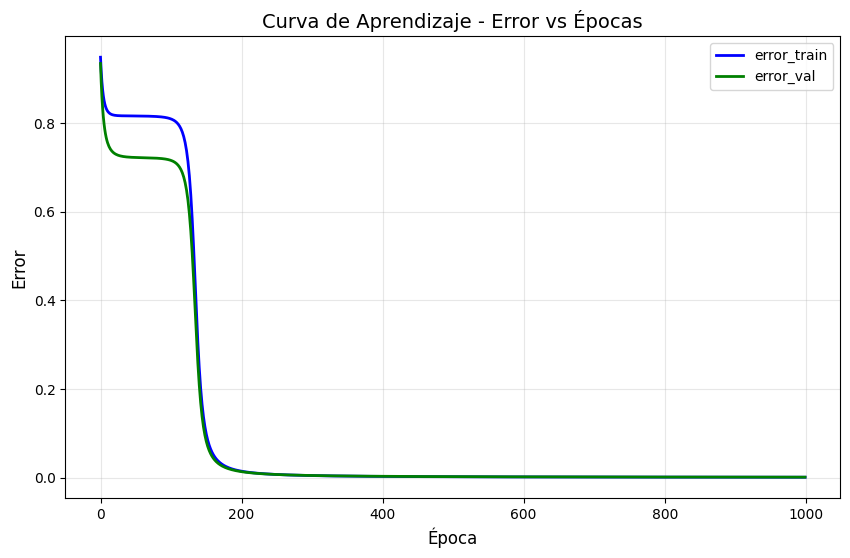

In [59]:
plt.figure(figsize=(10, 6))
plt.plot(model.epoch_error, color='blue', linewidth=2, label='error_train')
plt.plot(model.epoch_error_val, color='green', linewidth=2, label='error_val')
plt.xlabel('Época', fontsize=12)
plt.ylabel('Error', fontsize=12)
plt.title('Curva de Aprendizaje - Error vs Épocas', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Ejercicio 4 con todas las patologías

In [68]:
X, y = cargar_datos_csv(os.path.join(ruta_data, 'dermatology.csv'))

X = np.array(X)

y = np.array(y) - 1 # Así empieza en 0
y = y.flatten()
y = y.astype(int)

n_clases = np.max(y) + 1

Y = -np.ones((len(y), n_clases))
Y[np.arange(len(y)), y] = 1
y = Y

print(X.shape, y.shape)
print(Y)

(366, 34) (366, 6)
[[-1.  1. -1. -1. -1. -1.]
 [ 1. -1. -1. -1. -1. -1.]
 [-1. -1.  1. -1. -1. -1.]
 ...
 [-1. -1.  1. -1. -1. -1.]
 [-1. -1.  1. -1. -1. -1.]
 [ 1. -1. -1. -1. -1. -1.]]


In [69]:
modelos = []
for i in range(3):
    model = neural_network(
        layers_config = [(2, 'symmetry sigmoid'), (6, 'symmetry sigmoid')],
        size_input=X.shape[1],
        max_epoch = 200,
        learning_rate=0.005 + 0.005*i,
        error_threshold=1e-3,
        validation_proportion=0.2,
        paciencia = 20
    )   
    modelos.append(model)

k_fold = K_fold(modelos, k=5, muestreo_estratificado=True)

print(k_fold.cross_val(X,y))





(array([0.84976526, 0.79812207, 0.81220657, 0.8685446 , 0.82629108]), array([0.04353812, 0.02393906, 0.013279  , 0.02894091, 0.01756647]))


In [70]:
print(np.array(k_fold.metricas_modelos))
print()
print(np.mean(k_fold.metricas_modelos, axis=0))
print()
print(np.array(k_fold.matrices_confusion))

print("------------------")
print("REPORTE PICANTE")
print("------------------")
metrica_global, metricas_clases = k_fold.calcular_metrica_global_y_por_clase('sensibilidad')
print(f"Sensibilidad Global")
print(metrica_global)
print(f"Sensibilidad por clase")
print(metricas_clases)
print()
metrica_global, metricas_clases = k_fold.calcular_metrica_global_y_por_clase('especificidad')
print(f"Especificidad Global")
print(metrica_global)
print(f"Especificidad por clase")
print(metricas_clases)
print()
metrica_global, metricas_clases = k_fold.calcular_metrica_global_y_por_clase('precision')
print(f"Precisión Global")
print(metrica_global)
print(f"Precisión por clase")
print(metricas_clases)
print()
metrica_global, metricas_clases = k_fold.calcular_metrica_global_y_por_clase('exactitud')
print(f"Exactitud Global")
print(metrica_global)
print(f"Exactitud Promedio Global")
print(np.mean(metrica_global, axis=0))
print(f"Exactitud por clase")
print(metricas_clases)
print()
metrica_global, metricas_clases = k_fold.calcular_metrica_global_y_por_clase('F1')
print(f"F1 Global")
print(metrica_global)
print(f"F1 por clase")
print(metricas_clases)
print()

[[0.87323944 0.78873239 0.88732394]
 [0.78873239 0.77464789 0.83098592]
 [0.8028169  0.83098592 0.8028169 ]
 [0.87323944 0.83098592 0.90140845]
 [0.83098592 0.8028169  0.84507042]]

[0.83380282 0.8056338  0.85352113]

[[[[22.  0.  0.  0.  0.  0.]
   [ 0. 12.  0.  0.  0.  0.]
   [ 0.  0. 14.  0.  0.  0.]
   [ 0.  2.  3.  4.  0.  0.]
   [ 0.  0.  0.  0. 10.  0.]
   [ 0.  2.  2.  0.  0.  0.]]

  [[22.  0.  0.  0.  0.  0.]
   [ 0. 12.  0.  0.  0.  0.]
   [ 0.  0. 14.  0.  0.  0.]
   [ 0.  1.  0.  0.  8.  0.]
   [ 0.  1.  1.  0.  8.  0.]
   [ 1.  0.  0.  0.  3.  0.]]

  [[22.  0.  0.  0.  0.  0.]
   [ 0. 11.  0.  1.  0.  0.]
   [ 0.  0. 14.  0.  0.  0.]
   [ 0.  2.  0.  6.  1.  0.]
   [ 0.  0.  0.  0. 10.  0.]
   [ 2.  1.  0.  1.  0.  0.]]]


 [[[21.  1.  0.  0.  0.  0.]
   [ 0. 12.  0.  0.  0.  0.]
   [ 0.  0. 13.  0.  1.  0.]
   [ 0.  5.  3.  1.  0.  0.]
   [ 1.  0.  0.  0.  9.  0.]
   [ 1.  3.  0.  0.  0.  0.]]

  [[21.  0.  0.  0.  1.  0.]
   [ 0. 12.  0.  0.  0.  0.]
   [ 1.  0. 13.  0

C:\Users\franc\AppData\Local\Temp\ipykernel_18488\1888708542.py:212: RuntimeWarning: invalid value encountered in scalar divide
  precision = (TP) / (TP + FP)
C:\Users\franc\AppData\Local\Temp\ipykernel_18488\1888708542.py:263: RuntimeWarning: invalid value encountered in scalar divide
  precision = (TP) / (TP + FP)


# Ejercicio 5

In [63]:
ruta_data = os.path.abspath('../data')

X, y = cargar_datos_csv(os.path.join(ruta_data, 'dermatology.csv'))

X = np.array(X)

# encontrar la moda
valores, counts = np.unique(y, return_counts=True)
moda = valores[np.argmin(counts)]

#print(X[0,:])

# construir array binario
y = (y == moda).astype(int).flatten()
y = 2*y - 1

#print(moda)  
#print(y)  

# El ganador fue pityriasis rubra pilaris!!
# Hay 8 personas cuya edad tiene un '?', hice que al importar el dataset
# se ponga -1, así reemplazamos tras splittear con la media.

y = np.array(y)
print(X.shape, y.shape, np.mean(y))
print(y[y==1])
print(y)

(366, 34) (366,) -0.8907103825136612
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1 -1 -1 -1
 -1 -1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1  1 -1 -1 -1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1
  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1  1  1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1

In [64]:
modelos = []
for i in range(3):
    model = neural_network(
        layers_config = [(2, 'symmetry sigmoid'), (1, 'symmetry sigmoid')],
        size_input=X.shape[1],
        max_epoch = 200,
        learning_rate=0.005 + 0.005*i,
        error_threshold=1e-3,
        validation_proportion=0.2,
        paciencia = 20
    )   
    modelos.append(model)

k_fold = K_fold(modelos, k=5, muestreo_estratificado=True)

print(k_fold.cross_val(X,y))

(array([0.98630137, 0.98630137, 0.99543379, 1.        , 1.        ]), array([0.       , 0.       , 0.0064576, 0.       , 0.       ]))


In [65]:
print("------------------")
print("REPORTE PICANTE")
print("------------------")
metrica_global, metricas_clases = k_fold.calcular_metrica_global_y_por_clase('sensibilidad')
print(f"Sensibilidad Global")
print(metrica_global)
print(f"Sensibilidad por clase")
print(metricas_clases)
print()
metrica_global, metricas_clases = k_fold.calcular_metrica_global_y_por_clase('especificidad')
print(f"Especificidad Global")
print(metrica_global)
print(f"Especificidad por clase")
print(metricas_clases)
print()
metrica_global, metricas_clases = k_fold.calcular_metrica_global_y_por_clase('precision')
print(f"Precisión Global")
print(metrica_global)
print(f"Precisión por clase")
print(metricas_clases)
print()
metrica_global, metricas_clases = k_fold.calcular_metrica_global_y_por_clase('exactitud')
print(f"Exactitud Global")
print(metrica_global)
print(f"Exactitud por clase")
print(metricas_clases)
print()
metrica_global, metricas_clases = k_fold.calcular_metrica_global_y_por_clase('F1')
print(f"F1 Global")
print(metrica_global)
print(f"F1 por clase")
print(metricas_clases)
print()

------------------
REPORTE PICANTE
------------------
Sensibilidad Global
[0.99452055 0.99452055 0.99178082]
Sensibilidad por clase
[[0.98550725 1.        ]
 [0.98550725 1.        ]
 [0.98550725 1.        ]]

Especificidad Global
[0.99452055 0.99452055 0.99178082]
Especificidad por clase
[[1. 1.]
 [1. 1.]
 [1. 1.]]

Precisión Global
[0.99452055 0.99452055 0.99178082]
Precisión por clase
[[1. 1.]
 [1. 1.]
 [1. 1.]]

Exactitud Global
[0.99452055 0.99452055 0.99178082]
Exactitud por clase
[[0.98630137 1.        ]
 [0.98630137 1.        ]
 [0.98630137 1.        ]]

F1 Global
[0.99452055 0.99452055 0.99178082]
F1 por clase
[[0.99270073 1.        ]
 [0.99270073 1.        ]
 [0.99270073 1.        ]]



# Ejercicio 6

In [66]:
X, y = cargar_datos_csv(os.path.join(ruta_data, 'dermatology.csv'))

X = np.array(X)

y = np.array(y) - 1 # Así empieza en 0
y = y.flatten()
y = y.astype(int)

print(X.shape, y.shape)
print(y)

(366, 34) (366,)
[1 0 2 0 2 1 4 2 3 3 0 1 1 0 2 3 1 0 2 4 5 1 4 2 4 0 5 4 1 2 0 1 0 0 3 1 2
 1 2 0 1 3 0 1 4 2 3 5 1 2 2 3 0 0 4 0 1 2 3 1 5 0 4 0 1 2 0 3 4 0 1 5 2 4
 3 1 1 0 2 4 0 1 1 1 4 0 0 2 0 3 1 1 4 0 2 3 1 4 0 5 1 4 0 1 1 0 3 0 2 0 0
 2 4 2 2 4 1 2 3 0 1 4 5 0 0 1 5 2 4 3 0 0 2 4 4 0 3 1 2 0 1 0 0 2 2 2 1 4
 3 1 1 0 0 0 4 2 1 2 1 1 3 1 2 5 1 0 0 2 3 2 2 0 0 0 2 0 0 1 2 2 0 0 0 0 5
 1 1 1 1 0 2 2 2 0 0 1 2 1 1 1 4 4 4 4 4 0 0 0 0 0 0 0 2 2 2 2 2 2 3 3 3 3
 4 4 4 4 4 4 4 1 1 1 1 0 0 0 0 0 0 5 5 0 0 0 0 0 0 0 0 2 2 2 2 2 2 2 3 3 3
 3 3 3 4 4 4 4 5 5 5 3 3 3 0 0 0 0 0 1 1 3 3 3 0 0 1 1 1 2 2 2 2 0 0 0 0 4
 4 4 4 4 2 2 2 3 0 0 3 3 3 0 0 0 2 2 2 2 2 0 0 0 0 3 3 0 0 3 2 2 3 0 0 3 3
 4 4 0 0 4 4 2 0 4 4 5 5 3 3 5 5 5 0 0 0 4 4 0 0 0 0 1 1 3 3 2 2 0]


In [67]:
from sklearn.model_selection import StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scaler = StandardScaler()

accs, precs, recalls, f1s = [], [], [], []

for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Ahora si intercambiamos edades -1 por la media
    edad_media = np.mean(X_train[:,33])
    X_train[X_train[:,33] == -1, 33] = edad_media
    X_test[X_test[:,33] == -1, 33] = edad_media

    # Diferentes escalas de datos en features
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    model = MLPClassifier(
        hidden_layer_sizes=(10,),
        alpha=0.001,
        solver='lbfgs',
        max_iter=1000,
        random_state=42
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print(f"Matriz de confusión")
    print(confusion_matrix(y_test, y_pred))

    accs.append(accuracy_score(y_test, y_pred))
    precs.append(precision_score(y_test, y_pred, average='macro'))
    recalls.append(recall_score(y_test, y_pred, average='macro'))
    f1s.append(f1_score(y_test, y_pred, average='macro'))

print("Accuracy:", accs)
print("Mean Accuracy:", np.mean(accs))
print("Precision:", precs)
print("Mean Precision:", np.mean(precs))
print("Recall:", recalls)
print("Mean Recall:", np.mean(recalls))
print("F1:", f1s)
print("Mean F1:", np.mean(f1s))

Matriz de confusión
[[21  1  0  0  0  0]
 [ 0 13  0  0  0  0]
 [ 0  0 14  0  0  0]
 [ 0  0  0 10  0  0]
 [ 0  0  0  0 11  0]
 [ 0  0  0  0  0  4]]
Matriz de confusión
[[23  0  0  0  0  0]
 [ 0  9  0  3  0  0]
 [ 0  0 13  0  1  0]
 [ 0  1  0  8  0  0]
 [ 0  0  0  0 11  0]
 [ 0  0  0  0  0  4]]
Matriz de confusión
[[23  0  0  0  0  0]
 [ 0 11  0  1  0  0]
 [ 0  0 14  0  0  0]
 [ 0  0  0 10  0  0]
 [ 0  0  0  0 10  0]
 [ 0  0  0  0  0  4]]
Matriz de confusión
[[22  0  0  0  0  0]
 [ 0 11  0  1  0  0]
 [ 0  0 15  0  0  0]
 [ 0  1  0  9  0  0]
 [ 0  0  0  1  9  0]
 [ 0  0  0  0  0  4]]
Matriz de confusión
[[22  0  0  0  0  0]
 [ 0 10  0  2  0  0]
 [ 0  0 15  0  0  0]
 [ 0  2  0  8  0  0]
 [ 0  0  0  0 10  0]
 [ 0  0  0  0  0  4]]
Accuracy: [0.9864864864864865, 0.9315068493150684, 0.9863013698630136, 0.958904109589041, 0.9452054794520548]
Mean Accuracy: 0.961680858941133
Precision: [0.9880952380952381, 0.923989898989899, 0.9848484848484849, 0.9558080808080808, 0.938888888888889]
Mean Precisi